1. Как влияет размер сети на ошибку, т.е как влияет уменьшение/увеличение размера сети. Не только в ширину (добавление большего количества нейронов на слой), но и в глубину.

Я не смог найти четкой закономерности в изменении ошибки в зависимости от размеров сети, так как результаты после каждого запуска менялись совершенно рандомно. Например, при изменении количества нейронов в скрытом слое, когда оно было больше количества на входном (256 и 512 соответственно), я получил совершенно разные значения ошибки. От 2,3 до 3,4. Какая-то закономерность, конечно, прослеживалась, но только при сильных изменениях размеров (неважно в ширину или глубину), а при добавлении еще одного-двух слоев или увеличении кол-ва нейронов в 1.5 - 2 раза, значение ошибки было в пределах 2.5 – 3.2.  

2. Что происходит с оценкой потерь сети при добавлении регуляризации (L1, L2, L1_L2).

При использовании регуляризации L2 на входном слое и L1 на скрытом, были достигнуты лучше результаты 2,17. Если поменять их местами, то ситуация ухудшается. C L1 на обоих слоях ошибка больше, чем с L2. Наиболее стабильным мне показался вариант с L1_L2 на входном слое и L2 на скрытом.


3. Попробуй разные оптимизаторы, например, SGD, rmsprop и разный learning rate.

Лучшим оптимизатором для этой задачи является Adam.  rmsprop ведет себя в этой задаче немного хуже, а SGD хуже всех.
При использовании оптимизатора SGD  иногда выдавал значения nan. Адекватные значения выводятся при learning rate ~ 1e-3

4. Попробуйте разные активации, не только swish, но и tanh,к примеру.

При прочих равных, активация tanh работает хуже, точность результатов меньше примерно на 0.2
Поэкспериментировал с активацией на выходном слое, получил прикол в виде ошибки 20+, понял, что в задачах лин. регрессии его активировать не стоит
Попробовал использовать softmax, которая также не подходит для решения этой задачи (ошибка > 20)))))



Немного поэкспериментировал с эпохами. При 250 эпохах получил наилучший результат (2.1466).  Измененный код:

Сколько мы имеем данных:
(404, 13)
(102, 13)
Тип данных <class 'numpy.ndarray'> <class 'numpy.ndarray'>
Как вылядят данные:
[2.1770e-02 8.2500e+01 2.0300e+00 0.0000e+00 4.1500e-01 7.6100e+00
 1.5700e+01 6.2700e+00 2.0000e+00 3.4800e+02 1.4700e+01 3.9538e+02
 3.1100e+00]
Как выглядят наши ответы:
42.3
Epoch 1/250
35/35 [==============================] - 1s 7ms/step - loss: 596.8000 - mae: 22.3542 - val_loss: 454.6221 - val_mae: 19.9282
Epoch 2/250
35/35 [==============================] - 0s 3ms/step - loss: 465.9005 - mae: 19.9145 - val_loss: 219.2397 - val_mae: 12.4146
Epoch 3/250
35/35 [==============================] - 0s 3ms/step - loss: 137.9325 - mae: 9.7679 - val_loss: 96.7063 - val_mae: 6.6271
Epoch 4/250
35/35 [==============================] - 0s 3ms/step - loss: 49.5205 - mae: 5.3102 - val_loss: 46.5720 - val_mae: 3.6964
Epoch 5/250
35/35 [==============================] - 0s 3ms/step - loss: 33.1536 - mae: 3.9390 - val_loss: 35.7075 - val_mae: 3.1758
Epoch 6/250
35/35 [=====

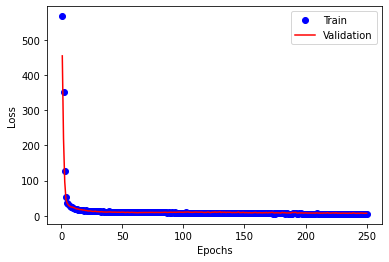

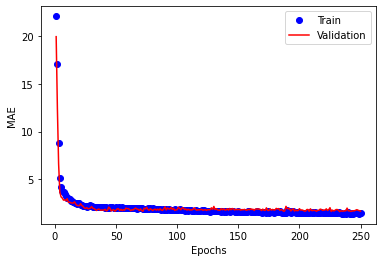

4/4 [==============================] - 0s 3ms/step - loss: 12.8965 - mae: 2.2461


In [152]:
import tensorflow.keras
from tensorflow.keras import layers
import numpy as np
from tensorflow.keras import models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.datasets import boston_housing
import matplotlib.pyplot as plt

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()


def show_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs, loss, 'bo', label='Training loss',color='b')
    plt.plot(epochs, val_loss, 'b', label='Validation loss', color='r')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    mae = history.history['mae']
    val_mae = history.history['val_mae']
    plt.plot(epochs, mae, 'bo', label='Training mae',color='b')
    plt.plot(epochs, val_mae, 'b', label='Validation mae',color='r')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()


def build_model():
    model = models.Sequential()
    model.add(layers.Dense(256, activation="swish", kernel_regularizer=tensorflow.keras.regularizers.l1_l2(l1=1e-2, l2=1e-4),
                           input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation="swish", kernel_regularizer=tensorflow.keras.regularizers.l2(l2=1e-6)))
    model.add(layers.Dense(1))
    # задача регрессии
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    return model


print("Сколько мы имеем данных:", train_data.shape, test_data.shape, sep="\n")
print("Тип данных", type(train_data), type(train_targets))
print("Как вылядят данные:", train_data[1], sep="\n")
print("Как выглядят наши ответы:", train_targets[1], sep="\n")

mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std

test_data -= mean
test_data /= std

# наивный вариант разделения данных на тренировочные и валидационные
val_data = train_data[:60]
val_targets = train_targets[:60]
train_data = train_data[60:]
train_targets = train_targets[60:]
model = build_model()

history = model.fit(train_data, train_targets,validation_data=(val_data,val_targets), epochs=250, batch_size=10)

#print(history.history.keys())

show_history(history)

val_mse, val_mae = model.evaluate(test_data, test_targets)



processing fold # 0


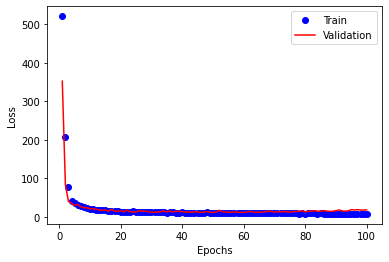

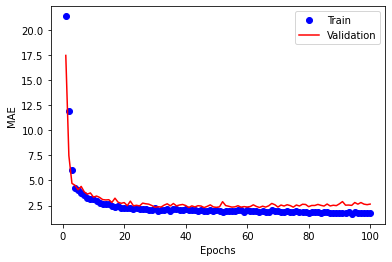

processing fold # 1


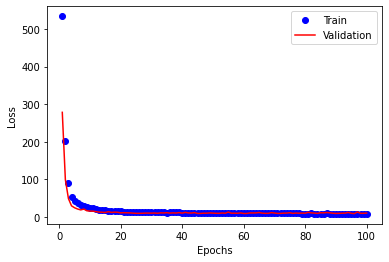

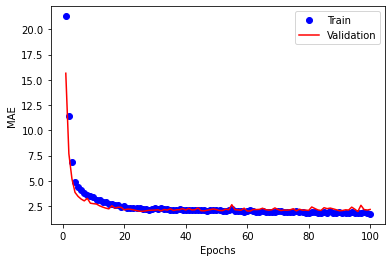

processing fold # 2


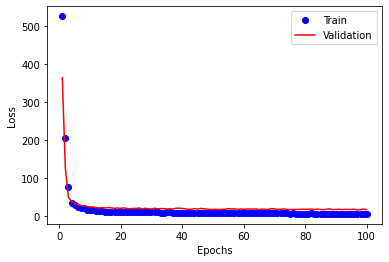

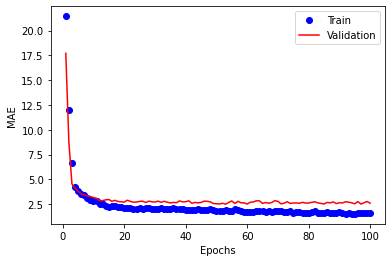

processing fold # 3


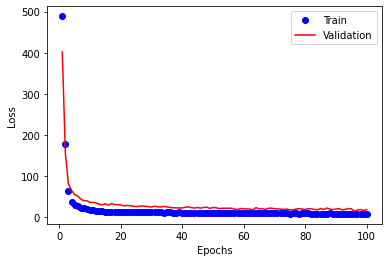

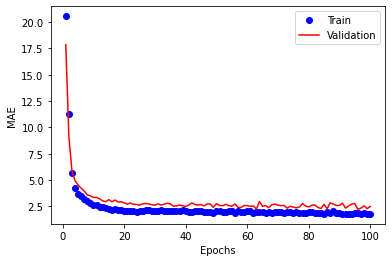

2.6067113280296326


In [153]:
# разделение на k блоков и оценка сети
k = 4
num_val_samples = len(train_data) // k
all_scores = []
for i in range(k):
    print('processing fold #', i)
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([train_data[:i * num_val_samples],
                                         train_data[(i + 1) * num_val_samples:]], axis=0)
    partial_train_targets = np.concatenate([train_targets[:i * num_val_samples],
                                            train_targets[(i + 1) * num_val_samples:]],
                                           axis=0)
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        epochs=100, validation_data=(val_data, val_targets), batch_size=5, verbose=0)
    show_history(history)
    val_mse, val_mae = model.evaluate(test_data, test_targets, verbose=0)
    all_scores.append(val_mae)

print(np.mean(all_scores))